In [83]:
import numpy as np
import pandas as pd
import random
import string
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, BertConfig
from transformers.models.bert.modeling_bert import BertEncoder
from sklearn.metrics import roc_auc_score
import os


In [104]:
from google.colab import files
uploaded = files.upload()  # ça va ouvrir le navigateur pour que tu choisisses le fichier


Saving llm-detect-ai-generated-text.zip to llm-detect-ai-generated-text.zip


In [105]:
import zipfile

zip_path = '/content/llm-detect-ai-generated-text.zip'  # adapte si le chemin diffère
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/llm_dataset')







In [106]:
TRAIN_PATH = '/content/llm_dataset/train_essays.csv'
TEST_PATH = '/content/llm_dataset/test_essays.csv'
PROMPT_PATH = '/content/llm_dataset/train_prompts.csv'
SRC_SUB = '/content/llm_dataset/sample_submission.csv'

def safe_read_csv(path):
  with open(TEST_PATH, encoding='latin1') as f:
    for i, line in enumerate(f):
        print(f"Ligne {i+1}: {line.strip().split(',')}")

    try:
        return pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        print(f"UTF-8 failed for {path}, trying latin1...")
        return pd.read_csv(path, encoding='latin1')

src_train = safe_read_csv(TRAIN_PATH)
src_prompt = safe_read_csv(PROMPT_PATH)
src_test = safe_read_csv(TEST_PATH)
src_sub = safe_read_csv(SRC_SUB)

print(src_test.head())


Ligne 1: ['ï»¿id', 'prompt_id', 'text']
Ligne 2: ['0000aaaa', '2', 'Aaa bbb ccc.']
Ligne 3: ['1111bbbb', '3', 'Bbb ccc ddd.']
Ligne 4: ['2222cccc', '4', 'CCC ddd eee.']
Ligne 5: ['hum1', '1', "Ce matin je me suis promenÃ© dans le parc et j'ai discutÃ© avec un ami de longue date. C'Ã©tait agrÃ©able de profiter du soleil."]
Ligne 6: ['hum2', '2', "Je me souviens encore du goÃ»t du pain frais achetÃ© Ã\xa0 la boulangerie du coin quand j'Ã©tais enfant."]
Ligne 7: ['hum3', '3', 'Les dÃ©fis Ã©conomiques actuels poussent de nombreux pays Ã\xa0 repenser leur modÃ¨le de croissance.']
Ligne 8: ['ia1', '4', 'Artificial intelligence is transforming industries by automating complex tasks and improving decision-making processes.']
Ligne 9: ['ia2', '5', "In conclusion technological advancements offer both challenges and opportunities for humanity's future."]
Ligne 10: ['ia3', '6', 'The quick brown fox jumps over the lazy dog. This sentence contains every letter of the English alphabet.']
Ligne 1: ['ï

In [107]:
print(src_train.head())
print(src_prompt.head())
print(src_sub.head())



         id  prompt_id                                               text  \
0  0059830c          0  Cars. Cars have been around since they became ...   
1  005db917          0  Transportation is a large necessity in most co...   
2  008f63e3          0  "America's love affair with it's vehicles seem...   
3  00940276          0  How often do you ride in a car? Do you drive a...   
4  00c39458          0  Cars are a wonderful thing. They are perhaps o...   

   generated  
0          0  
1          0  
2          0  
3          0  
4          0  
   prompt_id                       prompt_name  \
0          0                   Car-free cities   
1          1  Does the electoral college work?   

                                        instructions  \
0  Write an explanatory essay to inform fellow ci...   
1  Write a letter to your state senator in which ...   

                                         source_text  
0  # In German Suburb, Life Goes On Without Cars ...  
1  # What Is the 

In [82]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
pretrained_model = BertForSequenceClassification.from_pretrained('bert-base-uncased').to(device)
embedding_model = pretrained_model.bert  # est déjà sur le device !
print('pretrained_model.device:', next(pretrained_model.parameters()).device)
print('embedding_model.device:', next(embedding_model.parameters()).device)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


pretrained_model.device: cuda:0
embedding_model.device: cuda:0


In [71]:
train_batch_size = 8
test_batch_size = 16
lr = 2e-5
beta1 = 0.5
nz = 100
num_epochs = 5   # Mets 3-5 si tu veux de meilleurs résultats !
num_hidden_layers = 6
train_ratio = 0.8



In [65]:
class GANDAIGDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

all_num = len(src_train)
train_num = int(all_num * train_ratio)

# Split
train_set = src_train.sample(train_num, random_state=42)
test_set = src_train.drop(train_set.index).reset_index(drop=True)
train_set = train_set.reset_index(drop=True)

train_dataset = GANDAIGDataset(train_set['text'].tolist(), train_set['generated'].tolist())
test_dataset = GANDAIGDataset(test_set['text'].tolist(), test_set['generated'].tolist())

train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)


In [38]:
config = BertConfig(num_hidden_layers=num_hidden_layers)

class Generator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, 256 * 128)
        self.conv_net = nn.Sequential(
            nn.ConvTranspose1d(256, 128, 3, stride=2),
            nn.ReLU(),
            nn.ConvTranspose1d(128, 64, 3, stride=2),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, 3, stride=2),
            nn.ReLU()
        )
        # Add a linear layer to match the hidden size of BERT
        self.linear = nn.Linear(32, 768)
        self.bert_encoder = BertEncoder(config)

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 256, 128)
        x = self.conv_net(x)
        x = x.permute(0, 2, 1)  # (batch, seq_len, hidden_conv)
        x = self.linear(x)  # (batch, seq_len, hidden_bert)
        attn_mask = torch.ones(x.shape[:2]).to(x.device)
        ext_attn_mask = attn_mask.unsqueeze(1).unsqueeze(2)
        encoder_outputs = self.bert_encoder(
            hidden_states=x,
            attention_mask=ext_attn_mask,
            output_hidden_states=True,
            return_dict=True
        )
        return encoder_outputs

In [39]:
class SumBertPooler(torch.nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        # Pool sur la bonne dimension
        mean_embeddings = hidden_states.mean(dim=1)  # (batch, hidden_size)
        return mean_embeddings

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert_encoder = BertEncoder(config)
        self.bert_encoder.layer = nn.ModuleList([
            layer for layer in pretrained_model.bert.encoder.layer[:6]
        ])
        self.pooler = SumBertPooler()
        self.classifier = None  # On l'initialisera au 1er forward dynamiquement

    def forward(self, input):
        out = self.bert_encoder(input)
        pooled = self.pooler(out.last_hidden_state)  # (batch, hidden_size)
        if self.classifier is None:
            # On crée le Linear à la bonne taille à la volée
            in_features = pooled.shape[1]
            self.classifier = nn.Sequential(
                nn.Linear(in_features, 128),
                nn.ReLU(),
                nn.Linear(128, 1)
            ).to(pooled.device)
        out = self.classifier(pooled)
        return torch.sigmoid(out).view(-1)


In [40]:
def preparation_embedding(texts):
    encodings = tokenizer(list(texts), padding=True, truncation=True, return_tensors="pt")
    input_ids = encodings['input_ids'].to(device)
    token_type_ids = encodings['token_type_ids'].to(device)
    embeded = embedding_model(input_ids=input_ids, token_type_ids=token_type_ids)
    return embeded.last_hidden_state

def eval_auc(model):
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for batch in test_loader:
            encodings = tokenizer(list(batch[0]), padding=True, truncation=True, return_tensors="pt")
            input_ids = encodings['input_ids'].to(device)
            token_type_ids = encodings['token_type_ids'].to(device)
            embeded = embedding_model(input_ids=input_ids, token_type_ids=token_type_ids)
            embeded = embeded.last_hidden_state
            label = batch[1].float().to(device)
            outputs = model(embeded)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(label.cpu().numpy())
    auc = roc_auc_score(actuals, predictions)
    print("AUC:", auc)
    return auc

def get_model_info_dict(model, epoch, auc_score):
    current_device = next(model.parameters()).device
    model.to('cpu')
    model_info = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'auc_score': auc_score,
    }
    model.to(current_device)
    return model_info


In [41]:
def GAN_step(optimizerG, optimizerD, netG, netD, real_data, label, epoch, i):
    netD.zero_grad()
    batch_size = real_data.size(0)

    output = netD(real_data)
    errD_real = criterion(output, label)
    errD_real.backward()
    D_x = output.mean().item()

    noise = torch.randn(batch_size, nz, device=device)
    fake_data = netG(noise).last_hidden_state
    label_fake = torch.ones_like(label)
    output = netD(fake_data.detach())
    errD_fake = criterion(output, label_fake)
    errD_fake.backward()
    D_G_z1 = output.mean().item()
    errD = errD_real + errD_fake
    optimizerD.step()

    netG.zero_grad()
    label_g = torch.zeros_like(label)
    output = netD(fake_data)
    errG = criterion(output, label_g)
    errG.backward()
    D_G_z2 = output.mean().item()
    optimizerG.step()
    if i % 10 == 0:
        print('[%d/%d][%d/%d] Loss_D: %.4f Loss_G: %.4f D(x): %.4f D(G(z)): %.4f / %.4f'
              % (epoch, num_epochs, i, len(train_loader), errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))
    return optimizerG, optimizerD, netG, netD


In [42]:
netG = Generator(nz).to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

model_infos = []
for epoch in range(num_epochs):
    for i, data in enumerate(train_loader, 0):
        with torch.no_grad():
            embeded = preparation_embedding(data[0])
        label = data[1].float().to(device)
        optimizerG, optimizerD, netG, netD = GAN_step(
            optimizerG=optimizerG,
            optimizerD=optimizerD,
            netG=netG,
            netD=netD,
            real_data=embeded,
            label=label,
            epoch=epoch, i=i)
    auc_score = eval_auc(netD)
    model_infos.append(get_model_info_dict(netD, epoch, auc_score))

print('Train complete!')


[0/5][0/138] Loss_D: 1.2898 Loss_G: 0.9520 D(x): 0.4628 D(G(z)): 0.5126 / 0.6140
[0/5][10/138] Loss_D: 0.4376 Loss_G: 1.7067 D(x): 0.1732 D(G(z)): 0.7808 / 0.8185
[0/5][20/138] Loss_D: 0.3942 Loss_G: 1.7436 D(x): 0.1018 D(G(z)): 0.7507 / 0.8251
[0/5][30/138] Loss_D: 0.4743 Loss_G: 1.5210 D(x): 0.0731 D(G(z)): 0.6714 / 0.7815
[0/5][40/138] Loss_D: 0.2943 Loss_G: 1.9451 D(x): 0.0539 D(G(z)): 0.7875 / 0.8570
[0/5][50/138] Loss_D: 0.1806 Loss_G: 2.3097 D(x): 0.0467 D(G(z)): 0.8757 / 0.9007
[0/5][60/138] Loss_D: 0.2116 Loss_G: 2.4702 D(x): 0.0356 D(G(z)): 0.8392 / 0.9154
[0/5][70/138] Loss_D: 0.1248 Loss_G: 2.7398 D(x): 0.0351 D(G(z)): 0.9148 / 0.9354
[0/5][80/138] Loss_D: 0.1089 Loss_G: 2.9933 D(x): 0.0286 D(G(z)): 0.9232 / 0.9499
[0/5][90/138] Loss_D: 0.0737 Loss_G: 3.2584 D(x): 0.0306 D(G(z)): 0.9583 / 0.9615
[0/5][100/138] Loss_D: 0.0568 Loss_G: 3.4923 D(x): 0.0239 D(G(z)): 0.9679 / 0.9696
[0/5][110/138] Loss_D: 0.0463 Loss_G: 3.7176 D(x): 0.0209 D(G(z)): 0.9751 / 0.9757
[0/5][120/138] 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


AUC: nan
[1/5][0/138] Loss_D: 0.0574 Loss_G: 3.5124 D(x): 0.0183 D(G(z)): 0.9619 / 0.9702
[1/5][10/138] Loss_D: 0.0536 Loss_G: 3.4981 D(x): 0.0173 D(G(z)): 0.9645 / 0.9697
[1/5][20/138] Loss_D: 0.0741 Loss_G: 3.6821 D(x): 0.0170 D(G(z)): 0.9446 / 0.9748
[1/5][30/138] Loss_D: 0.0521 Loss_G: 3.5916 D(x): 0.0169 D(G(z)): 0.9656 / 0.9724
[1/5][40/138] Loss_D: 0.0457 Loss_G: 3.8186 D(x): 0.0166 D(G(z)): 0.9715 / 0.9780
[1/5][50/138] Loss_D: 0.0455 Loss_G: 3.9839 D(x): 0.0168 D(G(z)): 0.9718 / 0.9814
[1/5][60/138] Loss_D: 0.0353 Loss_G: 4.0493 D(x): 0.0142 D(G(z)): 0.9792 / 0.9826
[1/5][70/138] Loss_D: 0.0361 Loss_G: 4.1298 D(x): 0.0141 D(G(z)): 0.9783 / 0.9839
[1/5][80/138] Loss_D: 0.0304 Loss_G: 4.1845 D(x): 0.0134 D(G(z)): 0.9831 / 0.9848
[1/5][90/138] Loss_D: 0.0296 Loss_G: 4.2868 D(x): 0.0138 D(G(z)): 0.9844 / 0.9863
[1/5][100/138] Loss_D: 0.0463 Loss_G: 4.2547 D(x): 0.0315 D(G(z)): 0.9859 / 0.9858
[1/5][110/138] Loss_D: 0.0289 Loss_G: 4.2951 D(x): 0.0149 D(G(z)): 0.9862 / 0.9864
[1/5][

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


AUC: nan
[2/5][0/138] Loss_D: 0.0287 Loss_G: 4.1804 D(x): 0.0125 D(G(z)): 0.9840 / 0.9847
[2/5][10/138] Loss_D: 0.0284 Loss_G: 4.3315 D(x): 0.0144 D(G(z)): 0.9863 / 0.9869
[2/5][20/138] Loss_D: 0.0314 Loss_G: 4.1178 D(x): 0.0120 D(G(z)): 0.9809 / 0.9837
[2/5][30/138] Loss_D: 0.0292 Loss_G: 4.2542 D(x): 0.0128 D(G(z)): 0.9838 / 0.9858
[2/5][40/138] Loss_D: 0.0346 Loss_G: 4.0792 D(x): 0.0117 D(G(z)): 0.9775 / 0.9831
[2/5][50/138] Loss_D: 0.0250 Loss_G: 4.3837 D(x): 0.0118 D(G(z)): 0.9869 / 0.9875
[2/5][60/138] Loss_D: 0.0719 Loss_G: 4.6549 D(x): 0.0604 D(G(z)): 0.9904 / 0.9905
[2/5][70/138] Loss_D: 0.0252 Loss_G: 4.6994 D(x): 0.0158 D(G(z)): 0.9908 / 0.9909
[2/5][80/138] Loss_D: 0.0218 Loss_G: 4.7324 D(x): 0.0129 D(G(z)): 0.9912 / 0.9912
[2/5][90/138] Loss_D: 0.0213 Loss_G: 4.7271 D(x): 0.0123 D(G(z)): 0.9911 / 0.9911
[2/5][100/138] Loss_D: 0.0241 Loss_G: 4.5009 D(x): 0.0121 D(G(z)): 0.9881 / 0.9889
[2/5][110/138] Loss_D: 0.3835 Loss_G: 4.4449 D(x): 0.0222 D(G(z)): 0.9671 / 0.9883
[2/5][

...

AUC: nan
[3/5][0/138] Loss_D: 0.0246 Loss_G: 4.4878 D(x): 0.0127 D(G(z)): 0.9882 / 0.9888
[3/5][10/138] Loss_D: 0.1892 Loss_G: 4.4031 D(x): 0.0324 D(G(z)): 0.8557 / 0.9878
[3/5][20/138] Loss_D: 0.0494 Loss_G: 4.3528 D(x): 0.0322 D(G(z)): 0.9847 / 0.9871
[3/5][30/138] Loss_D: 0.1381 Loss_G: 4.8225 D(x): 0.0130 D(G(z)): 0.8825 / 0.9920
[3/5][40/138] Loss_D: 0.0202 Loss_G: 4.8484 D(x): 0.0122 D(G(z)): 0.9921 / 0.9922
[3/5][50/138] Loss_D: 0.0203 Loss_G: 4.8693 D(x): 0.0125 D(G(z)): 0.9923 / 0.9923
[3/5][60/138] Loss_D: 0.0222 Loss_G: 4.5855 D(x): 0.0116 D(G(z)): 0.9896 / 0.9898
[3/5][70/138] Loss_D: 0.0197 Loss_G: 4.8738 D(x): 0.0114 D(G(z)): 0.9918 / 0.9924
[3/5][80/138] Loss_D: 0.0204 Loss_G: 4.7556 D(x): 0.0116 D(G(z)): 0.9913 / 0.9914
[3/5][90/138] Loss_D: 0.1378 Loss_G: 4.5927 D(x): 0.0120 D(G(z)): 0.8818 / 0.9899
[3/5][100/138] Loss_D: 0.0241 Loss_G: 4.4586 D(x): 0.0113 D(G(z)): 0.9873 / 0.9884
[3/5][110/138] Loss_D: 0.0198 Loss_G: 4.7670 D(x): 0.0111 D(G(z)): 0.9914 / 0.9915
[3/5][

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


AUC: nan
[4/5][0/138] Loss_D: 0.0744 Loss_G: 4.8335 D(x): 0.0115 D(G(z)): 0.9391 / 0.9920
[4/5][10/138] Loss_D: 0.0294 Loss_G: 4.9231 D(x): 0.0219 D(G(z)): 0.9927 / 0.9927
[4/5][20/138] Loss_D: 0.1054 Loss_G: 4.8814 D(x): 0.0916 D(G(z)): 0.9922 / 0.9924
[4/5][30/138] Loss_D: 0.0255 Loss_G: 4.7375 D(x): 0.0164 D(G(z)): 0.9911 / 0.9912
[4/5][40/138] Loss_D: 0.0374 Loss_G: 4.6206 D(x): 0.0204 D(G(z)): 0.9834 / 0.9902
[4/5][50/138] Loss_D: 0.0446 Loss_G: 4.2902 D(x): 0.0156 D(G(z)): 0.9715 / 0.9863
[4/5][60/138] Loss_D: 0.0205 Loss_G: 4.9623 D(x): 0.0134 D(G(z)): 0.9930 / 0.9930
[4/5][70/138] Loss_D: 0.0190 Loss_G: 4.9877 D(x): 0.0121 D(G(z)): 0.9932 / 0.9932
[4/5][80/138] Loss_D: 0.0183 Loss_G: 5.0098 D(x): 0.0115 D(G(z)): 0.9933 / 0.9933
[4/5][90/138] Loss_D: 0.5211 Loss_G: 5.0286 D(x): 0.0122 D(G(z)): 0.9934 / 0.9935
[4/5][100/138] Loss_D: 0.0181 Loss_G: 5.0448 D(x): 0.0116 D(G(z)): 0.9935 / 0.9936
[4/5][110/138] Loss_D: 0.0175 Loss_G: 5.0599 D(x): 0.0110 D(G(z)): 0.9936 / 0.9937
[4/5][

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


AUC: nan
Train complete!


In [110]:
# Récupère le modèle avec le meilleur score AUC
max_auc_model_info = max(model_infos, key=lambda x: x['auc_score'])
model = Discriminator().to(device)

# FAKE FORWARD pour initialiser la couche classifier dynamiquement
with torch.no_grad():
    sample_texts = src_test['text'].tolist()[:2]  # Ou [:1]
    encodings = tokenizer(sample_texts, padding=True, truncation=True, return_tensors="pt")
    input_ids = encodings['input_ids'].to(device)
    token_type_ids = encodings['token_type_ids'].to(device)
    embeded = embedding_model(input_ids=input_ids, token_type_ids=token_type_ids).last_hidden_state
    model(embeded)  # Init de la couche classifier

# Chargement des poids appris
model.load_state_dict(max_auc_model_info['model_state_dict'])
model.eval()

# Dataset d'inférence
class InferenceDataset(torch.utils.data.Dataset):
    def __init__(self, texts):
        self.texts = texts
    def __getitem__(self, idx):
        return self.texts[idx]
    def __len__(self):
        return len(self.texts)

sub_dataset = InferenceDataset(src_test['text'].tolist())
test_batch_size = 16  # ou ton batch size préféré
inference_loader = DataLoader(sub_dataset, batch_size=test_batch_size, shuffle=False)

# Génération des prédictions
sub_predictions = []
with torch.no_grad():
    for batch in inference_loader:
        encodings = tokenizer(list(batch), padding=True, truncation=True, return_tensors="pt")
        input_ids = encodings['input_ids'].to(device)
        token_type_ids = encodings['token_type_ids'].to(device)
        embeded = embedding_model(input_ids=input_ids, token_type_ids=token_type_ids).last_hidden_state
        outputs = model(embeded)
        sub_predictions.extend(outputs.cpu().numpy())

# Création du DataFrame résultat
sub_ans_df = pd.DataFrame({
    "id": src_test['id'],
    "label": sub_predictions
})
print(sub_ans_df.head(10))

# Si tu veux sauvegarder la soumission :
sub_ans_df.to_csv("submission.csv", index=False)


         id     label
0  0000aaaa  0.972210
1  1111bbbb  0.971356
2  2222cccc  0.971429
3      hum1  0.095913
4      hum2  0.117744
5      hum3  0.424663
6       ia1  0.366809
7       ia2  0.841369
8       ia3  0.870213


<Axes: >

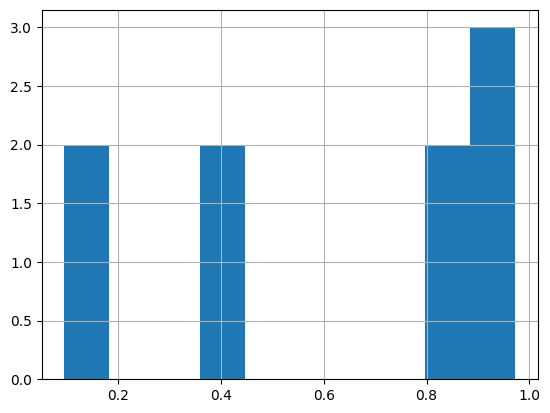

In [114]:
sub_ans_df['label'].hist()


In [112]:
sus = sub_ans_df.sort_values('label', ascending=False).head(10)
print(sus)


         id     label
0  0000aaaa  0.972210
2  2222cccc  0.971429
1  1111bbbb  0.971356
8       ia3  0.870213
7       ia2  0.841369
5      hum3  0.424663
6       ia1  0.366809
4      hum2  0.117744
3      hum1  0.095913


In [113]:
print(src_test.shape)


(9, 3)
